<a href="https://colab.research.google.com/github/shobhitgh-rs/Data-Science-Internship-Tasks/blob/main/SoftNesxisTasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Tasks
Task 1: Data Cleaning & Preprocessing

---



In [1]:
import pandas as pd
import numpy as np

# Data Ingestion
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
headers = ["symboling", "normalized_losses", "make", "fuel_type", "aspiration", "num_doors",
           "body_style", "drive_wheels", "engine_location", "wheel_base", "length", "width",
           "height", "curb_weight", "engine_type", "num_cylinders", "engine_size", "fuel_system",
           "bore", "stroke", "compression_ratio", "horsepower", "peak_rpm", "city_mpg",
           "highway_mpg", "price"]

df = pd.read_csv(url, header=None, names=headers)

print("--- RAW DATA ---")
display(df.head())

--- RAW DATA ---


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [2]:
# The dataset uses '?' for missing values.
df = df.replace("?", np.nan)

print("Missing Values Before Cleaning:")
missing_counts = df.isna().sum()
display(missing_counts[missing_counts > 0])

Missing Values Before Cleaning:


,0
normalized_losses,41
num_doors,2
bore,4
stroke,4
horsepower,2
peak_rpm,2
price,4


In [3]:
# Column Management & Deduplication
# Dropping 'normalized_losses'
df = df.drop(columns=["normalized_losses"])

df = df.drop_duplicates()
print("Duplicates and irrelevant columns removed.")

Duplicates and irrelevant columns removed.


In [4]:
# Data Type Correction
cols_to_numeric = ["price", "horsepower", "peak_rpm", "bore", "stroke"]

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Data types corrected.")

Data types corrected.


In [5]:
# Missing Value Handling
# Imputing the median for continuous data and mode for categorical data
df['price'] = df['price'].fillna(df['price'].median())
df['num_doors'] = df['num_doors'].fillna(df['num_doors'].mode()[0])

# Deleting rows for the remaining nulls
df = df.dropna(subset=["horsepower", "bore", "stroke", "peak_rpm"])

print("Missing values handled via imputation and deletion.")

Missing values handled via imputation and deletion.


In [6]:
# Format Standardization
# Normalizing text to be Title Case
df["make"] = df["make"].str.title()
df["body_style"] = df["body_style"].str.title()

print("--- AFTER CLEANING ---")
display(df.head())

print("\nTotal Missing Values Remaining (Should be 0):", df.isna().sum().sum())
print(f"Final Data Shape: {df.shape}")

--- AFTER CLEANING ---


,symboling,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,Alfa-Romero,gas,std,two,Convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,Alfa-Romero,gas,std,two,Convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,Alfa-Romero,gas,std,two,Hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,Audi,gas,std,four,Sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,Audi,gas,std,four,Sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0



Total Missing Values Remaining (Should be 0): 0
Final Data Shape: (199, 25)


Task 2: Exploratory Data Analysis (EDA)

---



In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
df = sns.load_dataset("titanic")

# Handle Missing Values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Print the shape
print("Data Shape:", df.shape)

Data Shape: (891, 15)


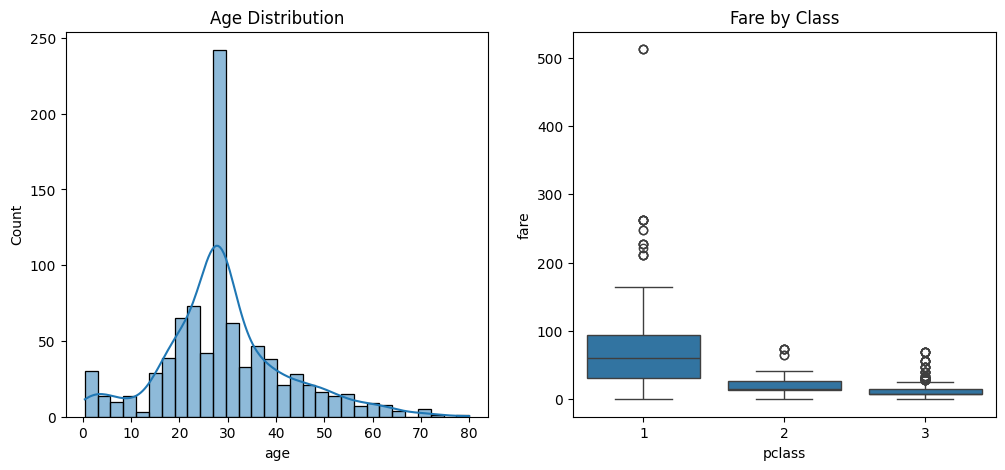

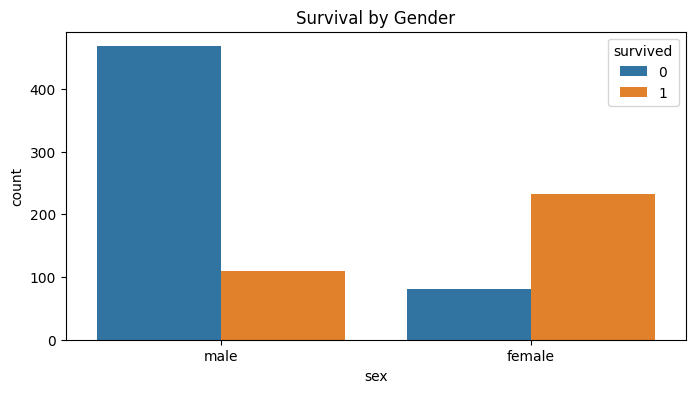

In [8]:
# Numerical Features (Histograms + Boxplots)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['age'], bins=30, kde=True, ax=ax[0]).set_title('Age Distribution')
sns.boxplot(x='pclass', y='fare', data=df, ax=ax[1]).set_title('Fare by Class')
plt.show()

# Categorical Features (Countplots)
plt.figure(figsize=(8, 4))
sns.countplot(x='sex', hue='survived', data=df).set_title('Survival by Gender')
plt.show()

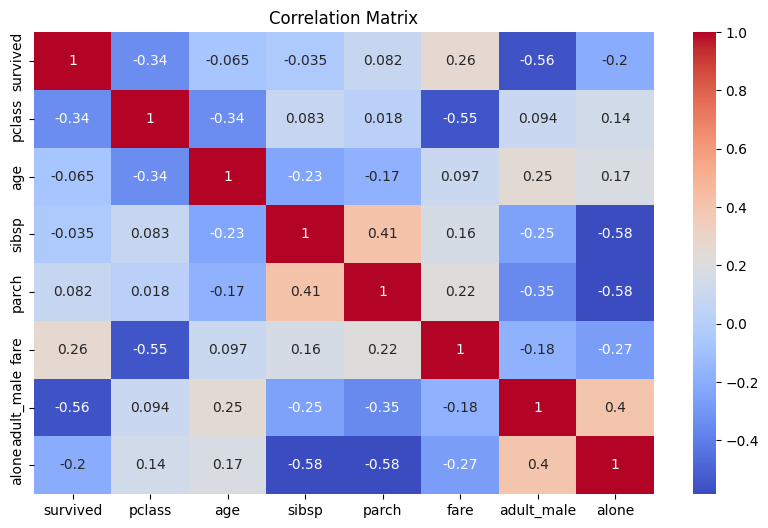

In [9]:
# Correlation Matrix (Heatmap)
plt.figure(figsize=(10, 6))
# numeric_only=True prevents errors with categorical text columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

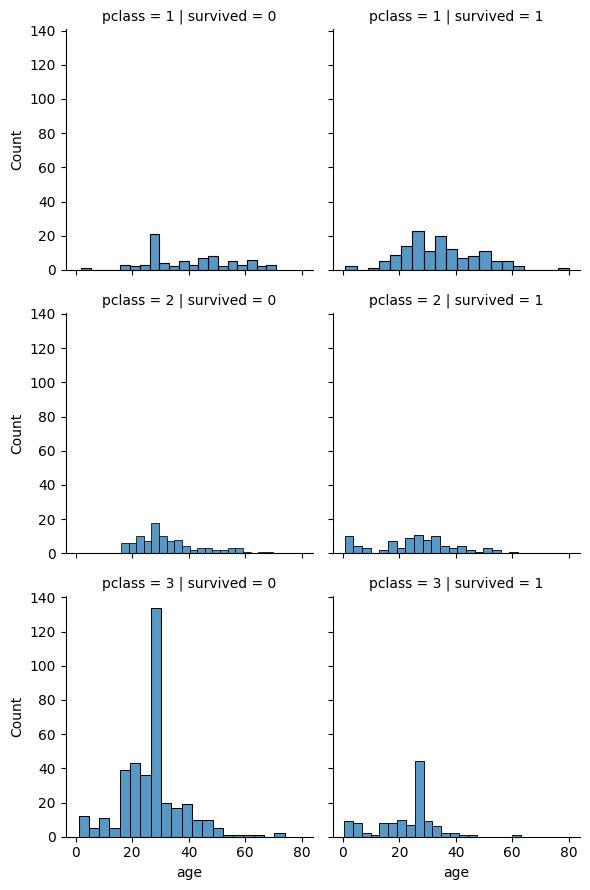

In [10]:
# FacetGrid
g = sns.FacetGrid(df, col='survived', row='pclass', height=3)
g.map(sns.histplot, 'age', bins=20)
plt.show()

Task 3: Exploratory Data Analysis (EDA)

---




In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

plt.style.use('ggplot')

In [12]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [13]:
print(df.info())

print()

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None

       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


In [14]:
df['Month'] = pd.to_datetime(df['Month'])

df.set_index('Month', inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


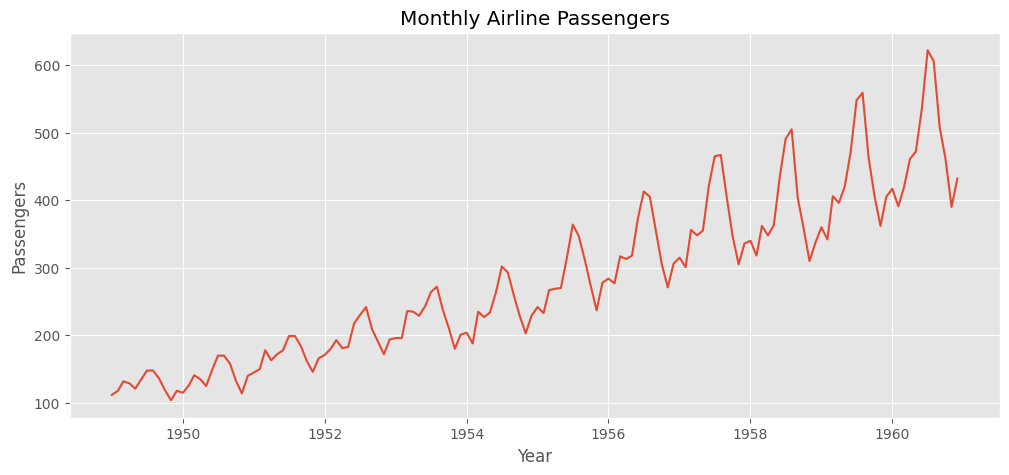

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df)

plt.title("Monthly Airline Passengers")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.show()

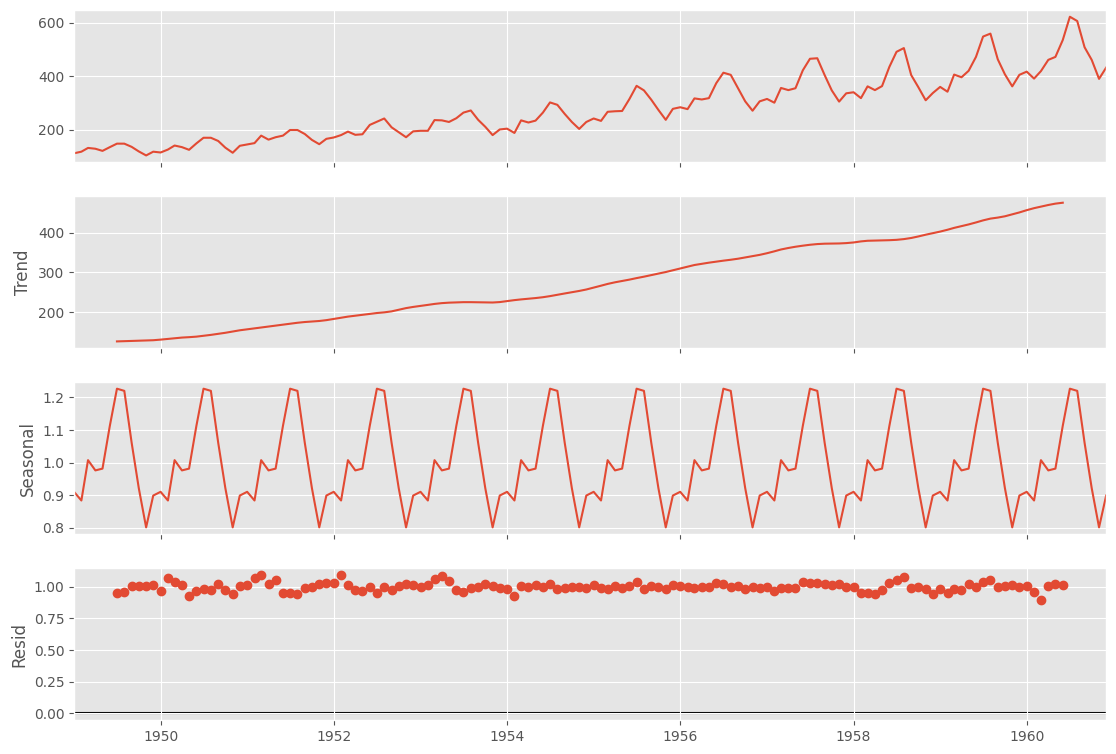

In [16]:
result = seasonal_decompose(df, model='multiplicative')

fig = result.plot()

fig.set_size_inches(12,8)

plt.show()

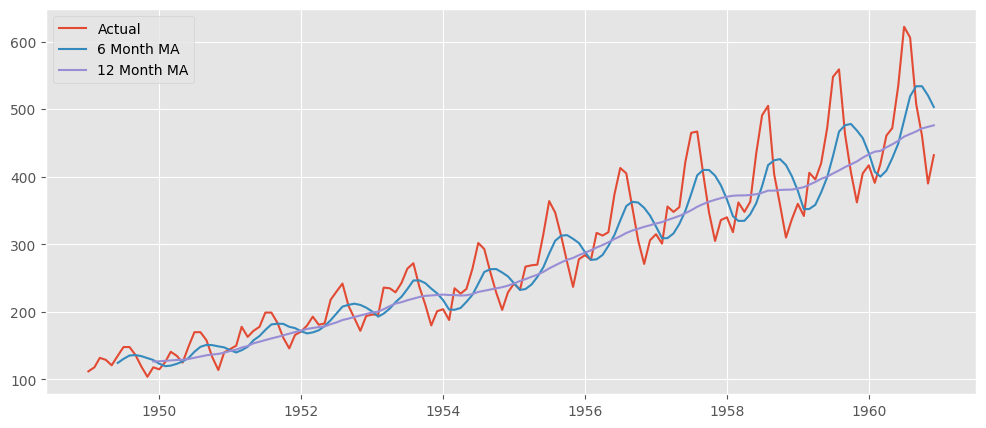

In [17]:
df['MA6'] = df['Passengers'].rolling(6).mean()

df['MA12'] = df['Passengers'].rolling(12).mean()

plt.figure(figsize=(12,5))

plt.plot(df['Passengers'],label='Actual')

plt.plot(df['MA6'],label='6 Month MA')

plt.plot(df['MA12'],label='12 Month MA')

plt.legend()

plt.show()

In [18]:
train = df.iloc[:-12]

test = df.iloc[-12:]

print(train.shape)

print(test.shape)

(132, 3)
(12, 3)


In [19]:
model = ARIMA(train['Passengers'],order=(2,1,1))

model_fit = model.fit()

model_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Passengers   No. Observations:                  132
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -619.131
Date:                Sun, 07 Jun 2026   AIC                           1246.262
Time:                        13:14:20   BIC                           1257.763
Sample:                    01-01-1949   HQIC                          1250.936
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0698      0.094     11.323      0.000       0.885       1.255
ar.L2         -0.4734      0.101     -4.670      0.000      -0.672      -0.275
ma.L1         -0.8402      0.085     -9.851      0.000      -1.007      -0.673
sigma2       741.2092     92.892      7.979      0.000     559.145     923.274
===================================================================================
Ljung-Box (L1) (Q):                   0.94   Jarque-Bera (JB):                 1.71
Prob(Q):                              0.33   Prob(JB):                         0.42
Heteroskedasticity (H):               6.69   Skew:                             0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
1960-01-01,437.013051
1960-02-01,450.903711
1960-03-01,450.608213
1960-04-01,443.715784
1960-05-01,436.482007
1960-06-01,432.006253
1960-07-01,430.642700
1960-08-01,431.302911
1960-09-01,432.654770
1960-10-01,433.788454


In [21]:
rmse = np.sqrt(mean_squared_error(test['Passengers'],forecast))

print("RMSE =",rmse)

RMSE = 87.8843772301304


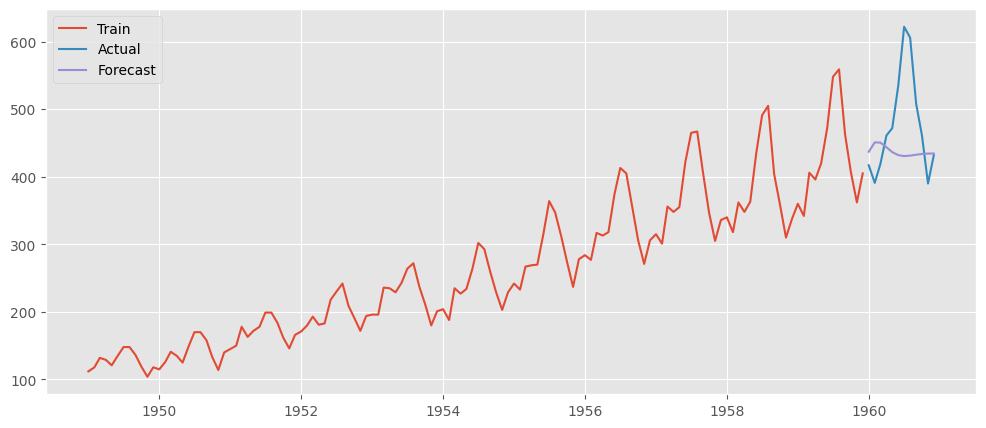

In [22]:
plt.figure(figsize=(12,5))

plt.plot(train.index,train['Passengers'],label='Train')

plt.plot(test.index,test['Passengers'],label='Actual')

plt.plot(test.index,forecast,label='Forecast')

plt.legend()

plt.show()

In [23]:
print("Business Insights")

print()

print("- Passenger demand shows a long-term increasing trend.")

print("- Seasonal patterns repeat annually.")

print("- Moving averages smooth short-term fluctuations.")

print("- ARIMA provides reasonable short-term forecasts.")

print("- Airlines can use these forecasts for capacity planning.")

Business Insights

- Passenger demand shows a long-term increasing trend.
- Seasonal patterns repeat annually.
- Moving averages smooth short-term fluctuations.
- ARIMA provides reasonable short-term forecasts.
- Airlines can use these forecasts for capacity planning.


Task 4: Exploratory Data Analysis (EDA)

---



In [24]:
print("Business Insights")

print()

print("- Passenger demand shows a long-term increasing trend.")

print("- Seasonal patterns repeat annually.")

print("- Moving averages smooth short-term fluctuations.")

print("- ARIMA provides reasonable short-term forecasts.")

print("- Airlines can use these forecasts for capacity planning.")

Business Insights

- Passenger demand shows a long-term increasing trend.
- Seasonal patterns repeat annually.
- Moving averages smooth short-term fluctuations.
- ARIMA provides reasonable short-term forecasts.
- Airlines can use these forecasts for capacity planning.


In [25]:
control_visitors = 10000
control_conversions = 750

treatment_visitors = 10000
treatment_conversions = 900

print("Control Conversion Rate:",
      control_conversions/control_visitors)

print("Treatment Conversion Rate:",
      treatment_conversions/treatment_visitors)

Control Conversion Rate: 0.075
Treatment Conversion Rate: 0.09


In [26]:
print("Null Hypothesis (H0):")
print("New design does NOT improve conversion rate.")

print()

print("Alternative Hypothesis (H1):")
print("New design improves conversion rate.")

Null Hypothesis (H0):
New design does NOT improve conversion rate.

Alternative Hypothesis (H1):
New design improves conversion rate.


In [27]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint

In [28]:
successes = [treatment_conversions,
             control_conversions]

samples = [treatment_visitors,
           control_visitors]

z_stat,p_value = proportions_ztest(
    successes,
    samples,
    alternative='larger'
)

print("Z Statistic:",z_stat)

print("P Value:",p_value)

Z Statistic: 3.8551941163203147
P Value: 5.7818918137101185e-05


In [29]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("New design performs better.")
else:
    print("Fail to reject H0")

Reject H0
New design performs better.


In [30]:
ci_control = proportion_confint(
    control_conversions,
    control_visitors,
    alpha=0.05
)

ci_treatment = proportion_confint(
    treatment_conversions,
    treatment_visitors,
    alpha=0.05
)

print("Control CI:",ci_control)

print("Treatment CI:",ci_treatment)

Control CI: (0.06983762452270609, 0.0801623754772939)
Treatment CI: (0.08439094056534566, 0.09560905943465434)


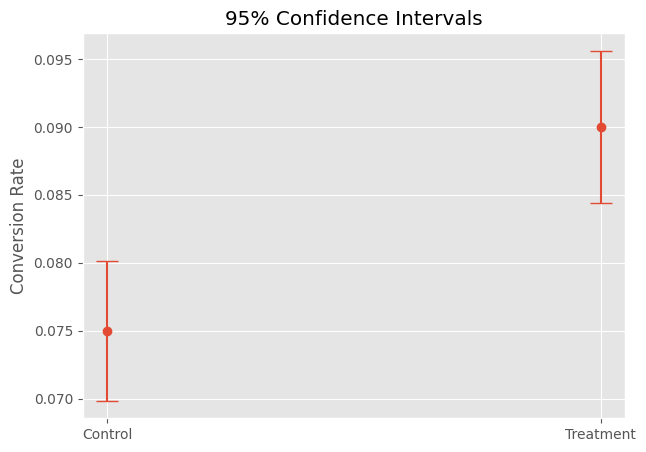

In [31]:
rates = [0.075,0.09]

errors = [
    [0.075-ci_control[0],
     0.09-ci_treatment[0]],

    [ci_control[1]-0.075,
     ci_treatment[1]-0.09]
]

plt.figure(figsize=(7,5))

plt.errorbar(
    [0,1],
    rates,
    yerr=errors,
    fmt='o',
    capsize=8
)

plt.xticks(
    [0,1],
    ['Control','Treatment']
)

plt.ylabel("Conversion Rate")

plt.title("95% Confidence Intervals")

plt.show()

In [32]:
from scipy.stats import chi2_contingency

In [33]:
table = np.array([
    [750,9250],
    [900,9100]
])

chi2,p,dof,expected = chi2_contingency(table)

print("Chi Square Statistic:",chi2)

print("P Value:",p)

Chi Square Statistic: 14.665015275369498
P Value: 0.00012840762825305565


In [34]:
from scipy.stats import ttest_ind

In [35]:
np.random.seed(42)

control = np.random.normal(
    300,
    40,
    100
)

treatment = np.random.normal(
    305,
    40,
    100
)

t_stat,p_val = ttest_ind(
    treatment,
    control
)

print("T Statistic:",t_stat)

print("P Value:",p_val)

T Statistic: 1.9071229436976984
P Value: 0.05795223882720417


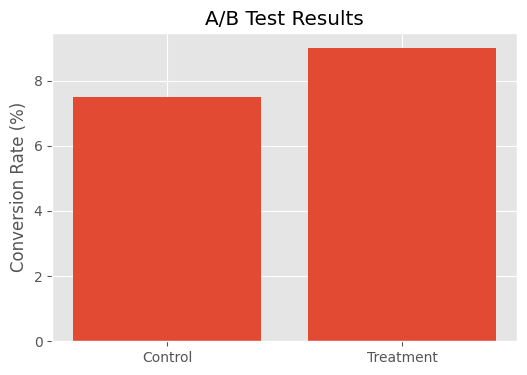

In [36]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Control','Treatment'],
    [7.5,9.0]
)

plt.ylabel("Conversion Rate (%)")

plt.title("A/B Test Results")

plt.show()

In [37]:
print("Business Findings")

print()

print("- Treatment conversion rate is higher.")

print("- Statistical testing supports improvement.")

print("- Confidence intervals indicate reliability.")

print("- Chi-square confirms group differences.")

print("- Recommend rolling out the new design.")

Business Findings

- Treatment conversion rate is higher.
- Statistical testing supports improvement.
- Confidence intervals indicate reliability.
- Chi-square confirms group differences.
- Recommend rolling out the new design.


In [38]:
print("Task 4 Completed Successfully!")

print()

print("Skills Demonstrated:")

print("1. Hypothesis Formulation")

print("2. A/B Testing")

print("3. Z-Test")

print("4. Confidence Intervals")

print("5. Chi-Square Test")

print("6. T-Test")

print("7. Business Decision Making")

Task 4 Completed Successfully!

Skills Demonstrated:
1. Hypothesis Formulation
2. A/B Testing
3. Z-Test
4. Confidence Intervals
5. Chi-Square Test
6. T-Test
7. Business Decision Making
